# CIBERSORT immune composition

**CIBERSORT 免疫细胞组成**

Estimate LM22 immune-cell fractions from the full STAD TPM matrix. `QN=False` is explicit for this RNA-seq example; 100 permutations are illustrative.

This notebook uses public [IOBR release fixtures](https://github.com/IOBR/IOBR/releases/tag/data-v1.0). Source URLs and checksums are in [data/manifest.json](data/manifest.json). Figures are descriptive; no clinical outcome labels are supplied.

**Setup:** from the repository root, install with `python -m pip install ".[tutorials]"`. Restart the notebook kernel after installation.

In [1]:
%matplotlib inline
from pathlib import Path
from time import perf_counter
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import iobrx

# Works from the repository root or from the tutorials directory.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tutorials" / "_common.py").exists())
sys.path.insert(0, str(ROOT / "tutorials"))
from _common import (configure, load, tpm_input, runtime_info, numeric_scores,
                     short_samples, clean_labels, panel, heatmap, scatter,
                     stacked, composition_figure, fractions, save_figure, save_result, COLORS, TEAL, RUST, NAVY)
configure(2)
iobrx.set_threads(8)
display(runtime_info())


{'iobrx': '0.2.0',
 'threads': 8,
 'native_available': True,
 'native_reason': None,
 'sorting': 'numpy CPU dispatch',
 'requires_avx512': False,
 'bundled_openblas_found': True,
 'versions': {'numpy': '2.2.6',
  'pandas': '2.3.3',
  'scipy': '1.16.3',
  'scikit-learn': '1.7.2',
  'iobrpy': '0.2.1',
  'gseapy': '1.3.1',
  'matplotlib': '3.10.9'}}

## 1. Inspect the input / 检查输入

Expression matrices are **genes × samples**. The analysis uses every sample; any figure subset is stated explicitly.

In [2]:
tpm = tpm_input()
input_shape = tpm.shape
display(tpm.iloc[:5, :4])


,TCGA-BR-6455,TCGA-BR-7196,TCGA-BR-8371,TCGA-BR-8380
MT-CO1,25097.553024,24055.972843,59199.134752,50164.981725
MT-ND4,14525.308129,14963.923341,48195.670862,32185.130734
MT-CO3,12465.198276,14835.808744,47590.766557,34559.374807
IGKC,9897.134453,78664.047321,713.537221,4372.862276
MT-CO2,12920.617435,13063.071078,33664.670548,21527.455301


## 2. Run the analysis / 运行分析

The timer covers the call below, including its resource setup. Data loading above and plotting below are excluded. This is a single run; repeated benchmark medians are reported separately in the README.

In [3]:
started = perf_counter()
result = iobrx.cibersort(tpm, perm=100, QN=False, n_threads=8)
elapsed = perf_counter() - started
display(save_result(result, "07_cibersort", elapsed, input_shape))

Completed in 26.760 s; input 48,058 features × 10 samples.


,analysis,seconds,input_shape,output_shapes,threads
0,07_cibersort,26.760327,"[48058, 10]","{'result': [10, 25]}",8


In [4]:
display(result.head() if isinstance(result, pd.DataFrame) else {key: value.shape if isinstance(value, pd.DataFrame) else list(value) for key, value in result.items()})

,B_cells_naive,B_cells_memory,Plasma_cells,T_cells_CD8,T_cells_CD4_naive,T_cells_CD4_memory_resting,T_cells_CD4_memory_activated,T_cells_follicular_helper,T_cells_regulatory_(Tregs),T_cells_gamma_delta,...,Macrophages_M2,Dendritic_cells_resting,Dendritic_cells_activated,Mast_cells_resting,Mast_cells_activated,Eosinophils,Neutrophils,P-value,Correlation,RMSE
TCGA-BR-6455,0.088018,0.000000,0.004347,0.261112,0.0,0.099646,0.032032,0.031990,0.077950,0.0,...,0.122305,0.013309,0.000000,0.000000,0.021757,0.000000e+00,0.000000,0.04,0.142950,1.034661
TCGA-BR-7196,0.159852,0.000000,0.126567,0.151311,0.0,0.158075,0.054754,0.005341,0.010555,0.0,...,0.096476,0.010721,0.000000,0.029035,0.000000,0.000000e+00,0.000000,0.00,0.354424,0.941350
TCGA-BR-8371,0.439738,0.000000,0.006137,0.073352,0.0,0.204795,0.000000,0.000000,0.143525,0.0,...,0.039394,0.000000,0.022864,0.011405,0.000000,2.348608e-07,0.000000,0.00,0.577687,0.815611
TCGA-BR-8380,0.118186,0.000000,0.026112,0.059556,0.0,0.240283,0.000000,0.012771,0.032688,0.0,...,0.134635,0.018166,0.000000,0.122600,0.000000,0.000000e+00,0.000000,0.01,0.197444,0.999419
TCGA-BR-8592,0.147667,0.006587,0.051735,0.123588,0.0,0.241790,0.036865,0.016731,0.035500,0.0,...,0.156302,0.012780,0.000000,0.114301,0.000000,0.000000e+00,0.005012,0.00,0.270746,0.974507


## 3. Visualize and export / 作图与导出

White background, restrained colors, thin axes and editable vector text. Display transformations do not overwrite the analysis result. `S01`, `S02`, … follow the input sample order, as recorded in the mapping table below.

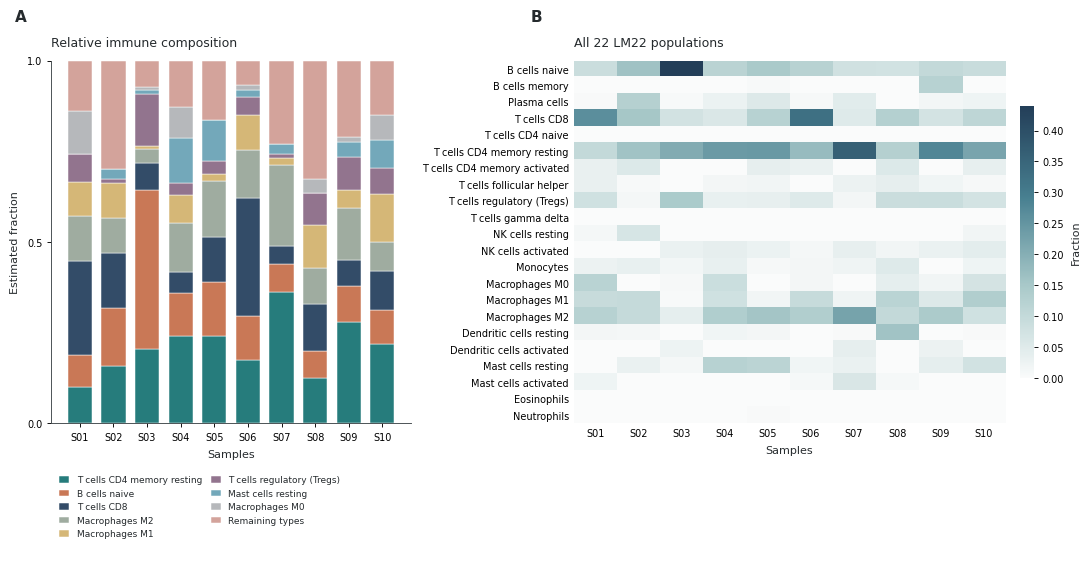

,P-value,Correlation,RMSE
TCGA-BR-6455,0.04,0.142950,1.034661
TCGA-BR-7196,0.00,0.354424,0.941350
TCGA-BR-8371,0.00,0.577687,0.815611
TCGA-BR-8380,0.01,0.197444,0.999419
TCGA-BR-8592,0.00,0.270746,0.974507
TCGA-BR-8686,0.03,0.156744,1.041206
TCGA-BR-A4IV,0.03,0.156815,1.022090
TCGA-BR-A4J4,0.04,0.145720,1.023935
TCGA-BR-A4J9,0.00,0.275819,0.976570
TCGA-FP-7916,0.04,0.135679,1.035649


In [5]:
cells = result.drop(columns=["P-value", "Correlation", "RMSE"])
fig, axes, legends = composition_figure(figsize=(10.8, 5.5), ratios=(1, 1.2))
stacked(axes[0], cells, max_types=8, legend_ax=legends[0])
heatmap(axes[1], cells.T, max_rows=22, max_samples=10, scale=False)
panel(axes[0], "A", "Relative immune composition")
panel(axes[1], "B", "All 22 LM22 populations")
save_figure(fig, '07_cibersort')
display(result[["P-value", "Correlation", "RMSE"]])


In [6]:
sample_ids = expression.columns if "expression" in globals() else counts.columns if "counts" in globals() else tpm.columns
display(pd.DataFrame({"plot_label": short_samples(sample_ids), "original_sample_id": sample_ids}).head(30))

,plot_label,original_sample_id
0,S01,TCGA-BR-6455
1,S02,TCGA-BR-7196
2,S03,TCGA-BR-8371
3,S04,TCGA-BR-8380
4,S05,TCGA-BR-8592
5,S06,TCGA-BR-8686
6,S07,TCGA-BR-A4IV
7,S08,TCGA-BR-A4J4
8,S09,TCGA-BR-A4J9
9,S10,TCGA-FP-7916


## 4. Interpretation and limits / 解读与边界

Relative CIBERSORT fractions describe the modeled immune mixture, not fractions of every cell in the tumor. The permutation p-value evaluates model fit and has a resolution of 1/100 here; it is not a cell-type differential-abundance p-value. Native P-values use a fixed seed; the explicit Python fallback keeps upstream stochastic behavior. The grouped bar chart combines the remaining LM22 types for display only.

**Reusing this tutorial:** replace the input-loading cell with your own `pd.read_csv(..., index_col=0)`; keep the matrix orientation, identifier type and expression scale consistent with this example. Check gene overlap before interpreting estimates.

Figures are written to `tutorials/figures/07_cibersort.png`, `.pdf`, and `.svg`. Compact output tables and timing metadata are written to `tutorials/results/`. Large count/TPM matrices remain in `result`; save them explicitly with `result.to_parquet(...)` if needed.